In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('titanic_toy.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [7]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [9]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [15]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [17]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,NaN,29.0


In [19]:
X_train.loc[X_train['Age_imputed'].isnull(),'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test.loc[X_test['Age_imputed'].isnull(),'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [21]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([33.  , 17.  , 17.  , 42.  , 35.  , 42.  , 29.  , 13.  , 40.5 ,
       44.  , 50.  , 19.  , 14.  , 27.  , 21.  , 34.  , 29.  , 30.  ,
       43.  , 40.5 ,  9.  , 70.  , 39.  , 42.  , 30.  ,  2.  , 22.  ,
       35.  , 15.  , 17.  ,  2.  , 14.  ,  8.  , 25.  , 26.  , 23.  ,
        0.75, 18.  , 31.  , 22.  , 20.  , 23.  , 22.  , 49.  , 45.  ,
       39.  , 40.  , 36.  , 21.  ,  7.  , 28.  ,  0.75, 19.  , 16.  ,
       24.  , 35.  , 45.  , 18.  , 18.  , 44.  , 37.  , 35.  , 40.  ,
       22.  , 21.  , 27.  , 16.  , 27.  , 40.  , 30.  , 31.  , 19.  ,
       28.  , 19.  , 30.  , 38.  , 16.  , 35.  , 27.  , 28.  , 50.  ,
        4.  , 24.  , 62.  , 39.  , 30.  , 29.  , 23.  , 18.  , 62.  ,
       60.  , 32.5 , 52.  , 23.  , 61.  , 65.  , 34.  , 17.  , 40.  ,
       18.  ,  6.  , 50.  , 18.  , 27.  , 23.  , 41.  , 27.  , 25.  ,
       35.  , 58.  , 48.  , 18.  , 30.  , 48.  , 54.  , 27.  , 39.  ,
       16.  , 24.  , 57.  , 49.  , 34.  , 28.  , 36.  , 42.  , 36.  ,
       57.  , 20.  ,

In [23]:
X_train['Age'].isnull().sum()

148

In [25]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,50.0
493,71.0,49.5042,71.0
527,NaN,221.7792,28.0


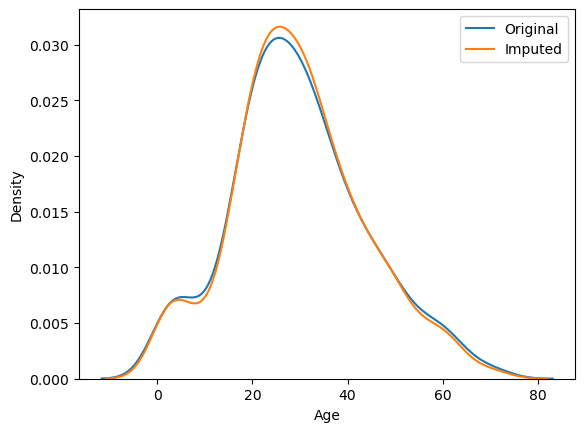

In [29]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')
plt.legend()
plt.show()

In [31]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  193.64789554433577


In [33]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2448.197914,70.719262,56.312502
Age,70.719262,204.349513,204.349513
Age_imputed,56.312502,204.349513,193.647896


<Axes: >

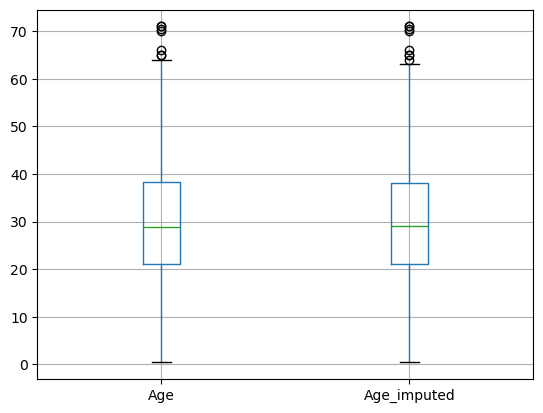

In [35]:
X_train[['Age', 'Age_imputed']].boxplot()

In [45]:
#sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [81]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [83]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [85]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [87]:
X = data
y = data['SalePrice']

In [89]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [91]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [97]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
427,NaN,TA,109008,TA,NaN
174,TA,TA,184000,TA,TA
224,Ex,TA,386250,TA,Ex
835,NaN,TA,128000,TA,NaN
867,NaN,TA,129000,TA,NaN


In [99]:
X_train.loc[X_train['GarageQual_imputed'].isnull(),'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test.loc[X_test['GarageQual_imputed'].isnull(),'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(),'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test.loc[X_test['FireplaceQu_imputed'].isnull(),'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [101]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [107]:
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [109]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.654321
TA,0.412439,0.533109
Fa,0.040917,0.051627
Po,0.027823,0.038159
Ex,0.024550,0.033670


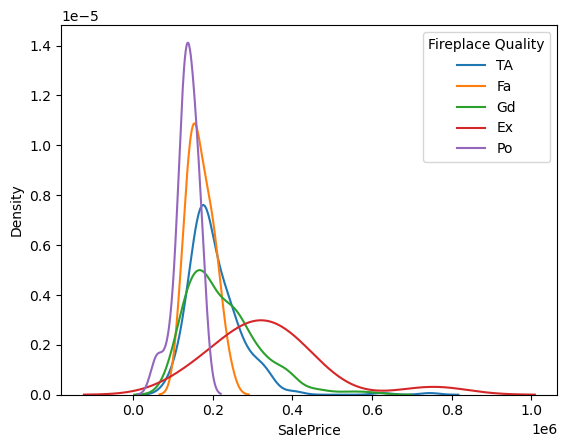

In [129]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
    plt.legend(title="Fireplace Quality")
plt.show()

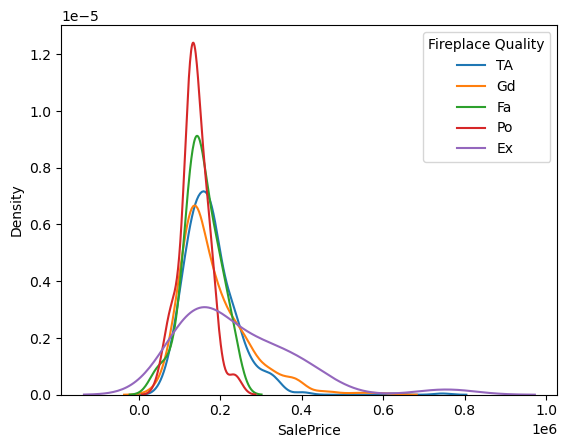

In [133]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
    plt.legend(title="Fireplace Quality")
plt.show()